# Entregable 2 — Experimentación Metodológica y Análisis Principal
## Predicción de Deserción Estudiantil: Invarianza entre PreTec21 y Tec21
**Equipo 7 · Desarrollo de Aplicaciones Avanzadas de Ciencias Computacionales**

---
Este notebook implementa experimentación sistemática con tres aproximaciones metodológicas (K-Means, Regresión Logística, Random Forest), comparación de resultados, y documentación de experimentos negativos.

### Estructura
- Exploración inicial 
- Flujo de trabajo de preprocesamiento (filtrado, ingeniería de variables, split temporal)
-  K-Means Clustering
-  Regresión Logística
-  Random Forest
- Comparación sistemática
- Experimentos negativos

##  Exploración Inicial
Análisis exploratorio base que motivó las decisiones metodológicas.

Importacion de Librerias

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, time, os
from pathlib import Path
from scipy import stats

Importacion de modulos

In [70]:
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

Imporrtacion de Funciones especificas

In [71]:

from sklearn.model_selection import (
    StratifiedKFold, cross_validate, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import (
    roc_auc_score, recall_score, f1_score, precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import silhouette_score, davies_bouldin_score


Preconfigrucacioniones globales

In [72]:
warnings.filterwarnings('ignore')

Variables Globbales

In [ ]:
SEED        = 42
TRAIN_GENS  = ['AD14', 'AD15', 'AD16', 'AD17', 'AD18']
TEST_GENS   = ['AD19', 'AD20']
TARGET      = 'retention'
K_CLUSTERS  = 4   # referencia de la Entrega 1
N_BOOTSTRAP = 1000

np.random.seed(SEED)
DATA_DIR = Path('../data')

print("Librerías cargadas correctamente.")
print(f"  sklearn  : {__import__('sklearn').__version__}")
print(f"  pandas   : {pd.__version__}")
print(f"  numpy    : {np.__version__}")

Librerías cargadas correctamente.
  sklearn  : 1.8.0
  pandas   : 3.0.3
  numpy    : 2.4.6


### Carga de datos 
La primera ejecución lee el `.xlsx` (~30 s) y guarda un CSV caché.
Las ejecuciones posteriores leen el CSV (~3 s).

In [36]:
CACHE_CSV = DATA_DIR / 'dataset_cache.csv'
XLSX_PATH = DATA_DIR / 'dataset.xlsx'

if CACHE_CSV.exists():
    t0 = time.time()
    df_raw = pd.read_csv(CACHE_CSV, low_memory=False)
    print(f"✓ Cache CSV cargado en {time.time()-t0:.1f}s  →  {df_raw.shape}")
else:
    print("Primera carga desde xlsx (puede tardar ~30s)...")
    t0 = time.time()
    df_raw = pd.read_excel(XLSX_PATH, engine='openpyxl')
    df_raw.to_csv(CACHE_CSV, index=False)
    print(f"✓ Xlsx leído y cache guardado en {time.time()-t0:.1f}s  →  {df_raw.shape}")

print(f"\nColumnas: {df_raw.columns.tolist()}")

✓ Cache CSV cargado en 0.8s  →  (143326, 50)

Columnas: ['student.id', 'generation', 'educational.model', 'level', 'gender', 'age', 'max.degree.parents', 'father.education.complete', 'father.education.summary', 'mother.education.complete', 'mother.education.summary', 'parents.exatec', 'father.exatec', 'mother.exatec', 'tec.no.tec', 'foreign', 'zone.type', 'first.generation', 'school', 'program', 'region', 'PNA', 'admission.test', 'online.test', 'english.evaluation', 'admission.rubric', 'general.math.eval', 'retention', 'FTE', 'scholarship.perc', 'scholarship.type', 'loan.perc', 'total.scholarship.loan', 'school.cost', 'id.school.origin', 'socioeconomic.level', 'social.lag', 'average.first.period', 'failed.subject.first.period', 'dropped.subject.first.period', 'dropout.semester', 'physical.education', 'cultural.diffusion', 'student.society', 'total.life.activities', 'athletic.sports', 'art.culture', 'student.society.leadership', 'life.work.mentoring', 'wellness.activities']


### Valores nulos por columna

In [37]:
nulls = df_raw.isnull().sum()
null_df = pd.DataFrame({
    'Nulos'      : nulls,
    '% del total': (nulls / len(df_raw) * 100).round(2)
}).query('Nulos > 0').sort_values('% del total', ascending=False)

print(f"Columnas con nulos: {len(null_df)}")
display(null_df)

Columnas con nulos: 5


,Nulos,% del total
average.first.period,99534,69.45
failed.subject.first.period,99534,69.45
dropped.subject.first.period,99534,69.45
admission.rubric,33489,23.37
admission.test,2177,1.52


### Desbalance de clases (dataset completo)

   Etiqueta      N     %
Desertó (0)  11639  8.12
 Retuvo (1) 131687 91.88


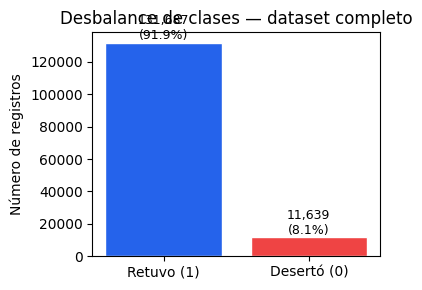

In [38]:
counts = df_raw['retention'].value_counts()
pcts   = df_raw['retention'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Etiqueta': ['Desertó (0)', 'Retuvo (1)'],
                    'N': [counts[0], counts[1]],
                    '%': [pcts[0].round(2), pcts[1].round(2)]}).to_string(index=False))

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Retuvo (1)', 'Desertó (0)'], [counts[1], counts[0]],
       color=['#2563eb', '#ef4444'], edgecolor='white')
ax.set_title('Desbalance de clases — dataset completo')
ax.set_ylabel('Número de registros')
for bar, val in zip(ax.patches, [counts[1], counts[0]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}\n({val/len(df_raw)*100:.1f}%)',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

### Correlación de variables numéricas con `retention`

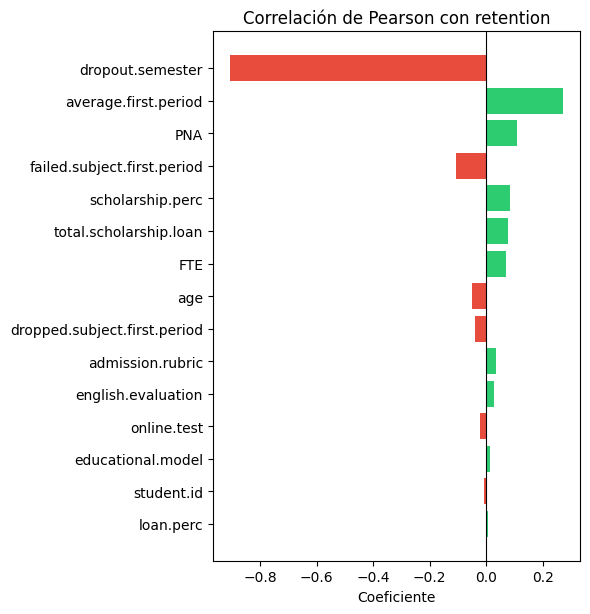

In [39]:
numeric_df = df_raw.select_dtypes(include='number')
corr = (numeric_df.corr()['retention'].drop('retention')
        .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(6, len(corr)*0.35 + 1))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Pearson con retention')
ax.set_xlabel('Coeficiente')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## Flujo de trabajo de Preprocesamiento
Implementa todas las decisiones del Componente 1:

| Paso | Acción |
|------|--------|
| Filtrado | Solo universitarios (AD14–AD20) |
| Exclusión | Variables de calificaciones (grado), identificadores, fuga de datos |
| MCAR | Imputar `admission_test_norm` y `admission.rubric` con mediana |
| MAR | `total.life.activities` → bandera binaria `has_extracurriculars` |
| MNAR | `first.generation` → categoría numérica (1/0/–1) |
| Ingeniería | `apoyo_financiero`, `educ_padres_max`, encoding de categóricas |
| Split | PreTec21 (AD14–18) = entrenamiento / Tec21 (AD19–20) = prueba |

In [40]:
# ── 1.1  Filtrar: solo universitarios ──────────────────────────────────────
df = df_raw[df_raw['level'] == 'Undergraduate'].copy()
print(f"Universitarios: {len(df):,} / {len(df_raw):,} ({len(df)/len(df_raw)*100:.1f}%)")
print(f"\nDistribución por generación:")
print(df['generation'].value_counts().sort_index().to_string())
print(f"\nModel 0 (PreTec21): {(df['educational.model']==0).sum():,}")
print(f"Model 1 (Tec21)   : {(df['educational.model']==1).sum():,}")

Universitarios: 77,517 / 143,326 (54.1%)

Distribución por generación:
generation
AD14    10143
AD15    10041
AD16    10742
AD17    10788
AD18    11296
AD19    12199
AD20    12308

Model 0 (PreTec21): 53,010
Model 1 (Tec21)   : 24,507


In [41]:
# ── 1.2  Eliminar columnas con fuga o irrelevantes ─────────────────────────
DROP_COLS = [
    'student.id',
    'level',                            # constante tras filtrar
    'average.first.period',             # solo en Tec21 → fuga
    'failed.subject.first.period',      # solo en Tec21 → fuga
    'dropped.subject.first.period',     # solo en Tec21 → fuga
    'dropout.semester',                 # derivado de retention → fuga
    'program',                          # alta cardinalidad, irrelevante
    'id.school.origin',                 # identificador
    'scholarship.type',                 # redundante con scholarship.perc
    'school.cost',                      # redundante con socioeconomic.level
    'general.math.eval',               # escala inconsistente, baja cobertura
    'parents.exatec', 'father.exatec', 'mother.exatec',   # redundantes
    'father.education.complete', 'father.education.summary',
    'mother.education.complete', 'mother.education.summary',
    'scholarship.perc', 'loan.perc',    # ya están en total.scholarship.loan
]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
print(f"Columnas tras exclusión: {df.shape[1]}  →  {df.columns.tolist()}")

Columnas tras exclusión: 30  →  ['generation', 'educational.model', 'gender', 'age', 'max.degree.parents', 'tec.no.tec', 'foreign', 'zone.type', 'first.generation', 'school', 'region', 'PNA', 'admission.test', 'online.test', 'english.evaluation', 'admission.rubric', 'retention', 'FTE', 'total.scholarship.loan', 'socioeconomic.level', 'social.lag', 'physical.education', 'cultural.diffusion', 'student.society', 'total.life.activities', 'athletic.sports', 'art.culture', 'student.society.leadership', 'life.work.mentoring', 'wellness.activities']


In [42]:
# ── 1.3  MCAR: normalizar admission.test (PAA 400-1600 y PAL 0-100) ────────
def norm_admission_test(val):
    """Normaliza PAA (>100) y PAL (0-100) a escala 0-1. 'Does not apply' → NaN."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if s.lower().startswith('does not'):
        return np.nan
    try:
        f = float(s)
        if f > 100:                    # PAA (rango 400–1600)
            return max(0.0, (f - 400) / 1200.0)
        elif f >= 0:                   # PAL (rango 0–100)
            return f / 100.0
    except Exception:
        pass
    return np.nan

df['admission_test_norm'] = df['admission.test'].apply(norm_admission_test)
df.drop(columns=['admission.test'], inplace=True)

# Imputar MCAR con mediana
med_at = df['admission_test_norm'].median()
med_ar = df['admission.rubric'].median()
df['admission_test_norm'].fillna(med_at, inplace=True)
df['admission.rubric'].fillna(med_ar, inplace=True)

print(f"admission_test_norm  — median imputado: {med_at:.3f}  | nulos restantes: {df['admission_test_norm'].isna().sum()}")
print(f"admission.rubric     — median imputado: {med_ar:.2f} | nulos restantes: {df['admission.rubric'].isna().sum()}")

admission_test_norm  — median imputado: 0.808  | nulos restantes: 25255
admission.rubric     — median imputado: 36.00 | nulos restantes: 29851


In [43]:
# ── 1.4  MAR: bandera binaria has_extracurriculars ──────────────────────────
ACTIVITY_COLS = [
    'physical.education', 'cultural.diffusion', 'student.society',
    'total.life.activities', 'athletic.sports', 'art.culture',
    'student.society.leadership', 'life.work.mentoring', 'wellness.activities'
]

def parse_activity(val):
    """Devuelve 1 si el estudiante participó en alguna actividad, 0 en otro caso."""
    if pd.isna(val):
        return 0
    s = str(val).strip()
    if s in ('Does not apply', 'No information', '', '0', '0.0'):
        return 0
    try:
        return int(float(s) > 0)
    except Exception:
        return 0

df['has_extracurriculars'] = df['total.life.activities'].apply(parse_activity)
df.drop(columns=[c for c in ACTIVITY_COLS if c in df.columns], inplace=True)
print(f"has_extracurriculars  →  con actividades: {df['has_extracurriculars'].sum():,} ({df['has_extracurriculars'].mean()*100:.1f}%)")

has_extracurriculars  →  con actividades: 30,371 (39.2%)


In [44]:
# ── 1.5  MNAR: first.generation → 3 categorías numéricas ──────────────────
def encode_first_gen(val):
    """Yes=1, No=0, No information=-1 (patrón MNAR; el modelo aprende la ausencia)."""
    s = str(val).strip()
    if s == 'Yes':           return  1
    if s == 'No':            return  0
    return -1   # 'No information'

df['first_gen_enc'] = df['first.generation'].apply(encode_first_gen)
df.drop(columns=['first.generation'], inplace=True)

vals = df['first_gen_enc'].value_counts().sort_index()
print("first_gen_enc — distribución:")
print(f"  -1 (No info / MNAR): {vals.get(-1,0):>6,} ({vals.get(-1,0)/len(df)*100:.1f}%)")
print(f"   0 (No)            : {vals.get(0,0):>6,} ({vals.get(0,0)/len(df)*100:.1f}%)")
print(f"   1 (Yes)           : {vals.get(1,0):>6,} ({vals.get(1,0)/len(df)*100:.1f}%)")

first_gen_enc — distribución:
  -1 (No info / MNAR): 37,372 (48.2%)
   0 (No)            : 34,752 (44.8%)
   1 (Yes)           :  5,393 (7.0%)


In [45]:
# ── 1.6  Ingeniería: educ_padres_max ────────────────────────────────────────
EDU_ORD = {
    'No information':     0,
    'No degree':          1,
    'Undergraduate degree': 2,
    'Master degree':      3,
    'PhD':                4,
}
df['educ_padres_max'] = df['max.degree.parents'].map(EDU_ORD).fillna(0).astype(int)
df.drop(columns=['max.degree.parents'], inplace=True)

# ── 1.7  apoyo_financiero = total.scholarship.loan (ya está calculado) ─────
df.rename(columns={'total.scholarship.loan': 'apoyo_financiero'}, inplace=True)

# ── 1.8  Encoding de categóricas ────────────────────────────────────────────
# gender
df['gender_enc'] = df['gender'].map({'Male': 1, 'Female': 0}).fillna(0).astype(int)
df.drop(columns=['gender'], inplace=True)

# tec.no.tec
df['tec_enc'] = df['tec.no.tec'].map({'TEC': 1, 'NO TEC': 0}).fillna(0).astype(int)
df.drop(columns=['tec.no.tec'], inplace=True)

# foreign
df['foreign_enc'] = df['foreign'].map({'Local': 0, 'Yes: National': 1, 'Yes: Foreigner': 2}).fillna(0).astype(int)
df.drop(columns=['foreign'], inplace=True)

# zone.type
df['zone_enc'] = df['zone.type'].map({'Rural': 0, 'Semiurban': 1, 'Urban': 2, 'No information': 1}).fillna(1).astype(int)
df.drop(columns=['zone.type'], inplace=True)

# socioeconomic.level → ordinal 0-7
sec_map = {'No information': 0, 'Level 1': 1, 'Level 2': 2, 'Level 3': 3,
           'Level 4': 4, 'Level 5': 5, 'Level 6': 6, 'Level 7': 7}
df['socioec_enc'] = df['socioeconomic.level'].map(sec_map).fillna(0).astype(int)
df.drop(columns=['socioeconomic.level'], inplace=True)

# social.lag
lag_map = {'No information': 0, 'Low': 1, 'Medium': 2, 'High': 3}
df['social_lag_enc'] = df['social.lag'].map(lag_map).fillna(0).astype(int)
df.drop(columns=['social.lag'], inplace=True)

# region → label encode
le_region = LabelEncoder()
df['region_enc'] = le_region.fit_transform(df['region'].fillna('Unknown'))
df.drop(columns=['region'], inplace=True)

# school → guardar string para análisis heterogeneidad + label encode
le_school = LabelEncoder()
df['school_enc'] = le_school.fit_transform(df['school'].fillna('Unknown'))
# conservamos columna 'school' para análisis de subgrupos

print("Columnas finales:", df.columns.tolist())
print("Shape final:", df.shape)
print("\nMissing restante:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Columnas finales: ['generation', 'educational.model', 'age', 'school', 'PNA', 'online.test', 'english.evaluation', 'admission.rubric', 'retention', 'FTE', 'apoyo_financiero', 'admission_test_norm', 'has_extracurriculars', 'first_gen_enc', 'educ_padres_max', 'gender_enc', 'tec_enc', 'foreign_enc', 'zone_enc', 'socioec_enc', 'social_lag_enc', 'region_enc', 'school_enc']
Shape final: (77517, 23)

Missing restante:
admission.rubric       29851
admission_test_norm    25255
dtype: int64


In [46]:
# ── 1.9  Split temporal ─────────────────────────────────────────────────────
FEATURE_COLS = [
    'PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric',
    'FTE', 'apoyo_financiero', 'has_extracurriculars',
    'first_gen_enc', 'educ_padres_max',
    'age', 'gender_enc', 'tec_enc', 'foreign_enc',
    'zone_enc', 'socioec_enc', 'social_lag_enc',
    'region_enc', 'school_enc', 'online.test'
]

CLUSTER_COLS = [   # subconjunto interpretable para clustering
    'PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric',
    'FTE', 'apoyo_financiero', 'has_extracurriculars',
    'first_gen_enc', 'educ_padres_max', 'socioec_enc', 'age'
]

train_mask = df['generation'].isin(TRAIN_GENS)
test_mask  = df['generation'].isin(TEST_GENS)

X_train = df.loc[train_mask, FEATURE_COLS].values
y_train = df.loc[train_mask, TARGET].values
X_test  = df.loc[test_mask,  FEATURE_COLS].values
y_test  = df.loc[test_mask,  TARGET].values

print(f"Entrenamiento (PreTec21) : {X_train.shape[0]:>6,} filas — deserción: {(y_train==0).mean()*100:.1f}%")
print(f"Prueba        (Tec21)   : {X_test.shape[0]:>6,} filas — deserción: {(y_test==0).mean()*100:.1f}%")
print(f"\nFeatures del modelo : {len(FEATURE_COLS)}")
print(f"Features del clustering: {len(CLUSTER_COLS)}")

# ── Imputación final de seguridad ────────────────────────────────────────────
# Captura cualquier NaN residual (e.g. PNA/FTE/age en subcohortes pequeñas)
# usando la mediana del conjunto de entrenamiento; nunca usa info del test.
from sklearn.impute import SimpleImputer
_nan_per_col = pd.isna(X_train).sum(axis=0)
if _nan_per_col.sum() > 0:
    print("\n⚠ NaN residuales en X_train:")
    for col, n in zip(FEATURE_COLS, _nan_per_col):
        if n > 0: print(f"  {col}: {n}")
else:
    print("\n✓ X_train sin NaN tras preprocesamiento")
imputer_final = SimpleImputer(strategy='median')
X_train = imputer_final.fit_transform(X_train)
X_test  = imputer_final.transform(X_test)
print("✓ Imputación de seguridad aplicada — X_train y X_test libres de NaN")

Entrenamiento (PreTec21) : 53,010 filas — deserción: 8.8%
Prueba        (Tec21)   : 24,507 filas — deserción: 8.7%

Features del modelo : 19
Features del clustering: 11

⚠ NaN residuales en X_train:
  admission_test_norm: 18124
  admission.rubric: 24376
✓ Imputación de seguridad aplicada — X_train y X_test libres de NaN


## K-Means Clustering
**Objetivo:** identificar perfiles latentes de riesgo sin etiquetas supervisadas y evaluar si esos perfiles persisten entre PreTec21 y Tec21 (invarianza).

**Protocolo:**
1. Estandarizar las variables del clustering con el escalador ajustado en PreTec21.
2. Determinar k óptimo con el método del codo + Silhouette.
3. Ajustar K-Means independientemente en PreTec21 y en Tec21.
4. Alinear clusters por similitud de perfiles z-score (coseno).
5. Reportar invarianza: variación < 15% en z-score por variable clave.

In [47]:
# ── 2.1a.1  Preparar datos de clustering ────────────────────────────────────
X_clust_train_df = df.loc[train_mask, CLUSTER_COLS].copy()
X_clust_test_df  = df.loc[test_mask,  CLUSTER_COLS].copy()

# Rellenar NaN residuales con mediana del train
clust_medians = X_clust_train_df.median()
X_clust_train_df.fillna(clust_medians, inplace=True)
X_clust_test_df.fillna(clust_medians, inplace=True)

scaler_clust = StandardScaler()
X_clust_train = scaler_clust.fit_transform(X_clust_train_df)
X_clust_test  = scaler_clust.transform(X_clust_test_df)

print(f"Train clustering shape: {X_clust_train.shape}")
print(f"Test  clustering shape: {X_clust_test.shape}")

Train clustering shape: (53010, 11)
Test  clustering shape: (24507, 11)


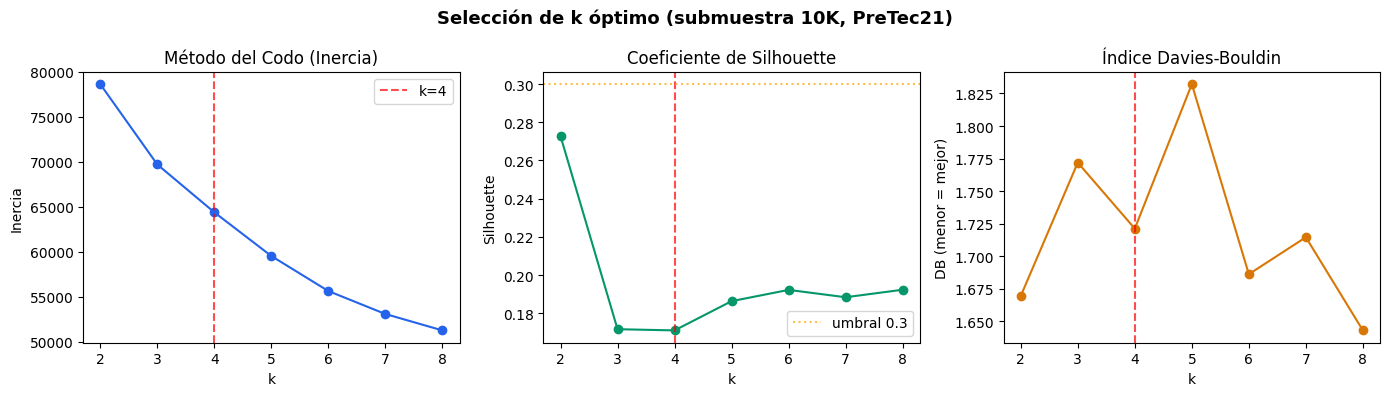


k=4 — Silhouette: 0.171  |  Davies-Bouldin: 1.721


In [48]:
# ── 2.1a.2  Método del codo + Silhouette para k óptimo ─────────────────────
inertias, silhouettes, db_scores = [], [], []
K_RANGE = range(2, 9)

# Submuestra para velocidad (10 000 puntos)
rng = np.random.default_rng(SEED)
idx_sub = rng.choice(len(X_clust_train), size=min(10_000, len(X_clust_train)), replace=False)
X_sub = X_clust_train[idx_sub]

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels = km.fit_predict(X_sub)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sub, labels, sample_size=3000, random_state=SEED))
    db_scores.append(davies_bouldin_score(X_sub, labels))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(list(K_RANGE), inertias, 'o-', color='#2563eb')
axes[0].set_title('Método del Codo (Inercia)'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[0].axvline(K_CLUSTERS, color='red', linestyle='--', alpha=0.7, label=f'k={K_CLUSTERS}')
axes[0].legend()

axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='#059669')
axes[1].set_title('Coeficiente de Silhouette'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette')
axes[1].axvline(K_CLUSTERS, color='red', linestyle='--', alpha=0.7)
axes[1].axhline(0.3, color='orange', linestyle=':', alpha=0.7, label='umbral 0.3')
axes[1].legend()

axes[2].plot(list(K_RANGE), db_scores, 'o-', color='#d97706')
axes[2].set_title('Índice Davies-Bouldin'); axes[2].set_xlabel('k'); axes[2].set_ylabel('DB (menor = mejor)')
axes[2].axvline(K_CLUSTERS, color='red', linestyle='--', alpha=0.7)

plt.suptitle('Selección de k óptimo (submuestra 10K, PreTec21)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\nk={K_CLUSTERS} — Silhouette: {silhouettes[K_CLUSTERS-2]:.3f}  |  Davies-Bouldin: {db_scores[K_CLUSTERS-2]:.3f}")

═══ Perfiles PreTec21 ═══
             n  dropout_rate  %_total
cluster                              
2         6103         0.182     11.5
1        18011         0.091     34.0
3        15375         0.082     29.0
0        13521         0.050     25.5


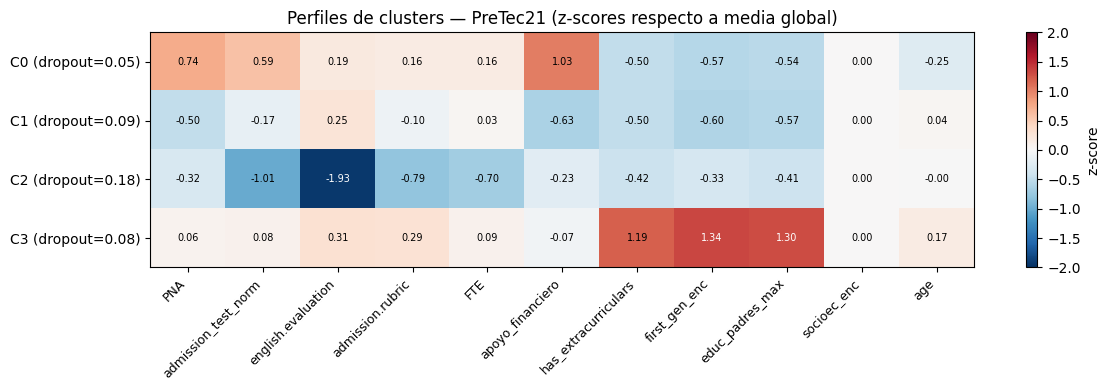

In [49]:
# ── 2.1a.3  Ajustar K-Means en PreTec21 y analizar perfiles ────────────────
km_train = KMeans(n_clusters=K_CLUSTERS, n_init=20, random_state=SEED)
labels_train = km_train.fit_predict(X_clust_train)

# Calcular tasa de deserción y tamaño por cluster
df_train = df.loc[train_mask].copy()
df_train['cluster'] = labels_train

cluster_stats_train = df_train.groupby('cluster').agg(
    n=('retention', 'count'),
    dropout_rate=('retention', lambda x: (x==0).mean())
).round(3)
cluster_stats_train['%_total'] = (cluster_stats_train['n'] / len(df_train) * 100).round(1)
cluster_stats_train = cluster_stats_train.sort_values('dropout_rate', ascending=False)
print("═══ Perfiles PreTec21 ═══")
print(cluster_stats_train.to_string())

# Heatmap de z-scores por cluster (respecto a la media global del train)
centers_df = pd.DataFrame(km_train.cluster_centers_, columns=CLUSTER_COLS)
centers_df.index = [f'C{i}' for i in range(K_CLUSTERS)]

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(centers_df.values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks(range(len(CLUSTER_COLS))); ax.set_xticklabels(CLUSTER_COLS, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(K_CLUSTERS)); ax.set_yticklabels([f'C{i} (dropout={cluster_stats_train.loc[i,"dropout_rate"]:.2f})' for i in range(K_CLUSTERS)])
plt.colorbar(im, ax=ax, label='z-score')
ax.set_title('Perfiles de clusters — PreTec21 (z-scores respecto a media global)', fontsize=12)
for i in range(K_CLUSTERS):
    for j in range(len(CLUSTER_COLS)):
        ax.text(j, i, f'{centers_df.values[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='white' if abs(centers_df.values[i,j]) > 1.2 else 'black')
plt.tight_layout(); plt.show()

Mapeo clusters Tec21 → PreTec21 (por similitud de perfil): {np.int64(2): np.int64(0), np.int64(0): np.int64(1), np.int64(3): np.int64(2), np.int64(1): np.int64(3)}

Diferencia absoluta en z-score por cluster y variable:
      PNA  admission_test_norm  english.evaluation  admission.rubric    FTE  apoyo_financiero  has_extracurriculars  first_gen_enc  educ_padres_max  socioec_enc    age
C0  0.040                0.078               0.004             0.430  0.856             0.211                 2.207          1.957            1.914        0.070  0.202
C1  0.763                0.411               0.468             0.509  0.751             0.785                 1.895          1.931            1.970        6.412  0.025
C2  0.256                0.257               0.676             1.137  0.174             0.027                 1.818          1.930            1.553        6.120  0.011
C3  0.473                0.880               0.273             0.015  0.895             0.596               

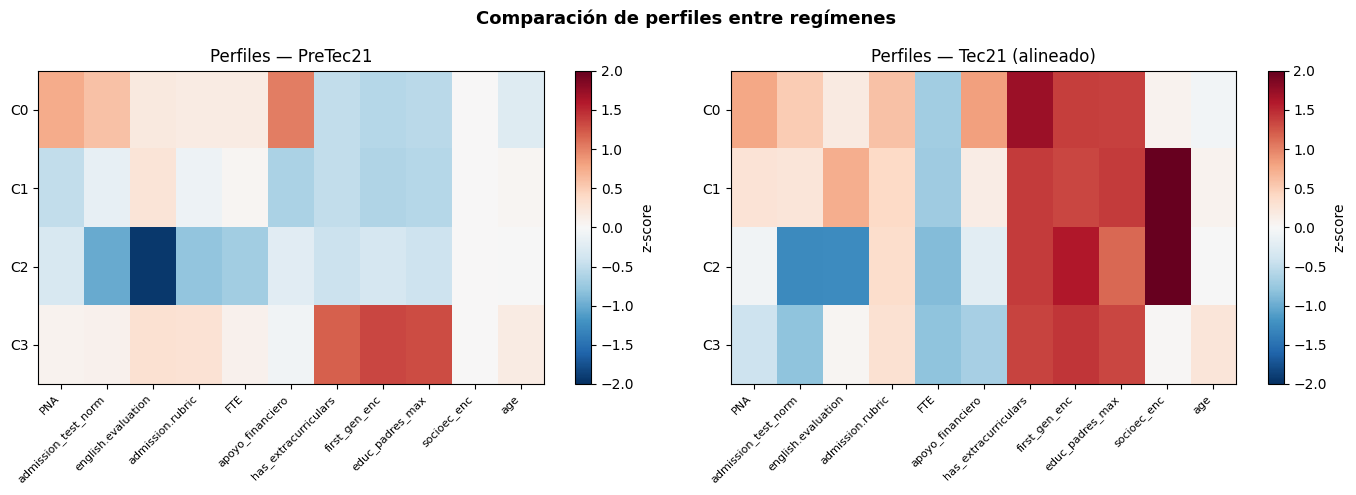


✓ Variables invariantes (Δz < 0.15): 0/11
✗ Variables que mutan (Δz ≥ 0.15)  : 11/11


In [50]:
# ── 2.1a.4  Ajustar K-Means en Tec21 y comparar invarianza ─────────────────
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

km_test = KMeans(n_clusters=K_CLUSTERS, n_init=20, random_state=SEED)
labels_test = km_test.fit_predict(X_clust_test)

df_test = df.loc[test_mask].copy()
df_test['cluster'] = labels_test

cluster_stats_test = df_test.groupby('cluster').agg(
    n=('retention', 'count'),
    dropout_rate=('retention', lambda x: (x==0).mean())
).round(3)
cluster_stats_test['%_total'] = (cluster_stats_test['n'] / len(df_test) * 100).round(1)

# ── Alinear clusters: Hungarian sobre similitud coseno ──────────────────────
centers_train = km_train.cluster_centers_
centers_test  = km_test.cluster_centers_
cost_mat = cdist(centers_train, centers_test, metric='cosine')
row_ind, col_ind = linear_sum_assignment(cost_mat)
mapping_test2train = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
print("Mapeo clusters Tec21 → PreTec21 (por similitud de perfil):", mapping_test2train)

# ── Diferencia en z-score por variable (invarianza) ────────────────────────
centers_test_aligned = centers_test[col_ind]   # reordenar según mapeo
diff = np.abs(centers_train[row_ind] - centers_test_aligned)  # diferencia absoluta

diff_df = pd.DataFrame(diff, columns=CLUSTER_COLS,
                        index=[f'C{row_ind[i]}' for i in range(len(row_ind))])
print("\nDiferencia absoluta en z-score por cluster y variable:")
print(diff_df.round(3).to_string())
print(f"\nVariables con diferencia máxima > 0.15 (umbral invarianza):")
max_diff = diff_df.max(axis=0)
print(max_diff[max_diff > 0.15].sort_values(ascending=False).to_string())

# ── Visualización comparativa ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, centers, title in [(axes[0], centers_train[row_ind], 'PreTec21'),
                             (axes[1], centers_test_aligned, 'Tec21 (alineado)')]:
    im = ax.imshow(centers, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
    ax.set_xticks(range(len(CLUSTER_COLS))); ax.set_xticklabels(CLUSTER_COLS, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(K_CLUSTERS)); ax.set_yticklabels([f'C{row_ind[i]}' for i in range(len(row_ind))])
    ax.set_title(f'Perfiles — {title}')
    plt.colorbar(im, ax=ax, label='z-score')
plt.suptitle('Comparación de perfiles entre regímenes', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Resultado de invarianza ─────────────────────────────────────────────────
invariant = (diff_df.max(axis=0) < 0.15).sum()
print(f"\n✓ Variables invariantes (Δz < 0.15): {invariant}/{len(CLUSTER_COLS)}")
print(f"✗ Variables que mutan (Δz ≥ 0.15)  : {len(CLUSTER_COLS)-invariant}/{len(CLUSTER_COLS)}")

## Regresión Logística
**Rol:** línea base interpretable y herramienta de comparación teórica.
Los coeficientes con IC permiten cuantificar cuánto cambia el efecto de cada predictor entre PreTec21 y Tec21.

In [51]:
# ── 2.1b.1  Estandarizar features del modelo ────────────────────────────────
scaler_model = StandardScaler()
X_train_sc = scaler_model.fit_transform(X_train)
X_test_sc   = scaler_model.transform(X_test)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"K-Fold estratificado: k=5, seed={SEED}")
print(f"Desertores en train: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")

K-Fold estratificado: k=5, seed=42
Desertores en train: 4,685 (8.8%)


In [52]:
# ── 2.1b.2  K-Fold CV sobre PreTec21 ────────────────────────────────────────
lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED, solver='lbfgs')

cv_lr = cross_validate(
    lr, X_train_sc, y_train,
    cv=skf,
    scoring=['roc_auc', 'recall', 'f1', 'precision'],
    return_train_score=True,
    n_jobs=-1
)

print("Regresión Logística — K-Fold CV (PreTec21):")
print(f"  AUC-ROC  : {cv_lr['test_roc_auc'].mean():.3f} ± {cv_lr['test_roc_auc'].std():.3f}")
print(f"  Recall   : {cv_lr['test_recall'].mean():.3f} ± {cv_lr['test_recall'].std():.3f}")
print(f"  F1-Score : {cv_lr['test_f1'].mean():.3f} ± {cv_lr['test_f1'].std():.3f}")
print(f"  Precision: {cv_lr['test_precision'].mean():.3f} ± {cv_lr['test_precision'].std():.3f}")

Regresión Logística — K-Fold CV (PreTec21):
  AUC-ROC  : 0.674 ± 0.009
  Recall   : 0.665 ± 0.004
  F1-Score : 0.780 ± 0.003
  Precision: 0.943 ± 0.002


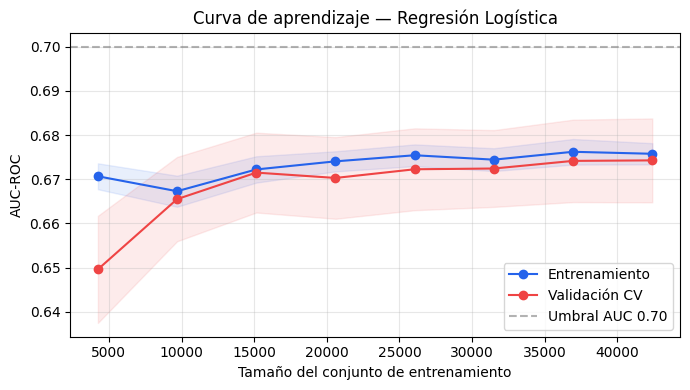

In [53]:
# ── 2.1b.3  Curva de aprendizaje ─────────────────────────────────────────────
train_sizes, tr_scores, val_scores = learning_curve(
    lr, X_train_sc, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=skf, scoring='roc_auc', n_jobs=-1
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_sizes, tr_scores.mean(1),  'o-', color='#2563eb', label='Entrenamiento')
ax.plot(train_sizes, val_scores.mean(1), 'o-', color='#ef4444',  label='Validación CV')
ax.fill_between(train_sizes, tr_scores.mean(1)-tr_scores.std(1), tr_scores.mean(1)+tr_scores.std(1), alpha=0.1, color='#2563eb')
ax.fill_between(train_sizes, val_scores.mean(1)-val_scores.std(1), val_scores.mean(1)+val_scores.std(1), alpha=0.1, color='#ef4444')
ax.axhline(0.7, color='gray', linestyle='--', alpha=0.6, label='Umbral AUC 0.70')
ax.set_xlabel('Tamaño del conjunto de entrenamiento'); ax.set_ylabel('AUC-ROC')
ax.set_title('Curva de aprendizaje — Regresión Logística')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [54]:
# ── 2.1b.4  Selección de umbral (OOF) + modelo final ────────────────────────
oof_proba_lr = np.zeros(len(X_train_sc))
for tr_idx, val_idx in skf.split(X_train_sc, y_train):
    lr.fit(X_train_sc[tr_idx], y_train[tr_idx])
    oof_proba_lr[val_idx] = lr.predict_proba(X_train_sc[val_idx])[:, 1]

prec_oof, rec_oof, thr_oof = precision_recall_curve(y_train, oof_proba_lr)
f1_oof = 2 * prec_oof * rec_oof / (prec_oof + rec_oof + 1e-8)
best_thr_lr = thr_oof[np.argmax(f1_oof[:-1])]
print(f"Umbral óptimo (OOF, max-F1): {best_thr_lr:.3f}")

# Modelo final entrenado en todo PreTec21
lr_final = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED, solver='lbfgs')
lr_final.fit(X_train_sc, y_train)
y_proba_lr = lr_final.predict_proba(X_test_sc)[:, 1]
y_pred_lr  = (y_proba_lr >= best_thr_lr).astype(int)

# ── Bootstrap IC 95% ────────────────────────────────────────────────────────
rng_bs = np.random.default_rng(SEED)
boot_aucs_lr, boot_rec_lr, boot_f1_lr = [], [], []
n_test = len(y_test)
for _ in range(N_BOOTSTRAP):
    idx = rng_bs.integers(0, n_test, n_test)
    if len(np.unique(y_test[idx])) < 2: continue
    boot_aucs_lr.append(roc_auc_score(y_test[idx], y_proba_lr[idx]))
    y_b = (y_proba_lr[idx] >= best_thr_lr).astype(int)
    boot_rec_lr.append(recall_score(y_test[idx], y_b, zero_division=0))
    boot_f1_lr.append(f1_score(y_test[idx], y_b, zero_division=0))

def ci(arr): return np.percentile(arr, [2.5, 97.5])
auc_lr   = roc_auc_score(y_test, y_proba_lr)
rec_lr   = recall_score(y_test, y_pred_lr)
f1_lr    = f1_score(y_test, y_pred_lr)
prec_lr  = precision_score(y_test, y_pred_lr)

print(f"\n─── Resultados en Tec21 (umbral={best_thr_lr:.2f}) ───")
print(f"  AUC-ROC  : {auc_lr:.3f}  IC95% [{ci(boot_aucs_lr)[0]:.3f}–{ci(boot_aucs_lr)[1]:.3f}]")
print(f"  Recall   : {rec_lr:.3f}  IC95% [{ci(boot_rec_lr)[0]:.3f}–{ci(boot_rec_lr)[1]:.3f}]")
print(f"  F1-Score : {f1_lr:.3f}  IC95% [{ci(boot_f1_lr)[0]:.3f}–{ci(boot_f1_lr)[1]:.3f}]")
print(f"  Precision: {prec_lr:.3f}")

Umbral óptimo (OOF, max-F1): 0.075

─── Resultados en Tec21 (umbral=0.07) ───
  AUC-ROC  : 0.655  IC95% [0.643–0.668]
  Recall   : 0.999  IC95% [0.999–1.000]
  F1-Score : 0.955  IC95% [0.953–0.956]
  Precision: 0.914


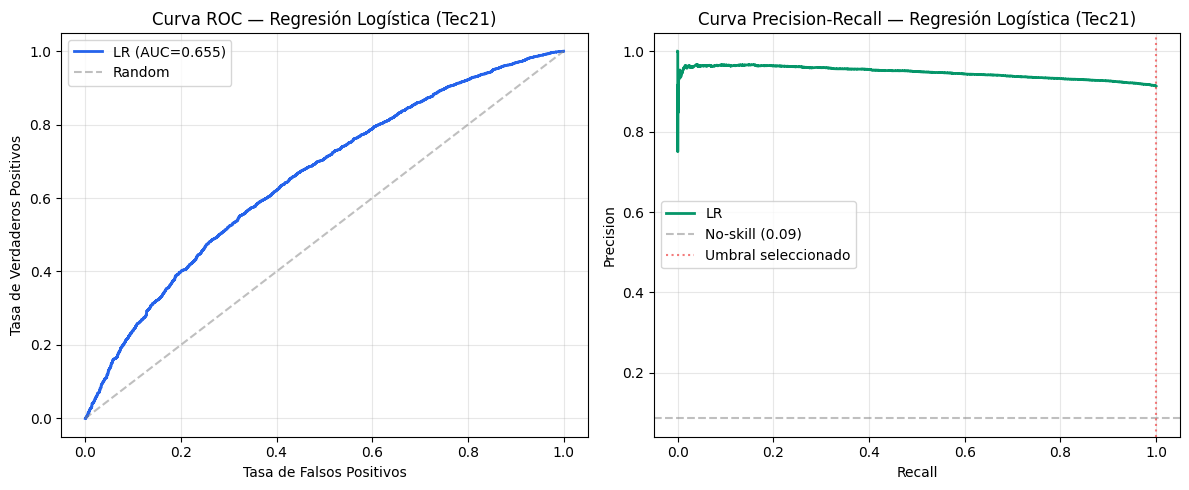

In [55]:
# ── 2.1b.5  Curvas ROC y Precision-Recall ───────────────────────────────────
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
prec_lr_c, rec_lr_c, _ = precision_recall_curve(y_test, y_proba_lr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(fpr_lr, tpr_lr, lw=2, color='#2563eb', label=f'LR (AUC={auc_lr:.3f})')
axes[0].plot([0,1],[0,1],'--', color='gray', alpha=0.5, label='Random')
axes[0].set_xlabel('Tasa de Falsos Positivos'); axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curva ROC — Regresión Logística (Tec21)'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Precision-Recall
no_skill = (y_test == 0).mean()
axes[1].plot(rec_lr_c, prec_lr_c, lw=2, color='#059669', label='LR')
axes[1].axhline(no_skill, linestyle='--', color='gray', alpha=0.5, label=f'No-skill ({no_skill:.2f})')
axes[1].axvline(rec_lr, linestyle=':', color='#ef4444', alpha=0.7, label=f'Umbral seleccionado')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — Regresión Logística (Tec21)'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

Perfil promedio por tipo de error:
               PNA  apoyo_financiero  has_extracurriculars  first_gen_enc
error_type                                                               
FN          71.229             0.158                 0.615          0.615
FP          86.174             0.149                 0.696          0.187
OK          88.304             0.243                 0.804          0.119


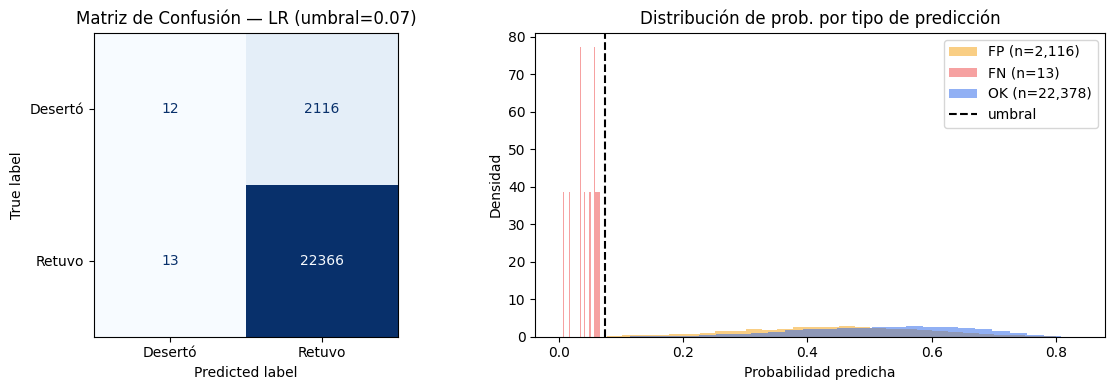

In [56]:
# ── 2.1b.6  Matriz de confusión + análisis de errores ───────────────────────
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

disp = ConfusionMatrixDisplay(cm_lr, display_labels=['Desertó', 'Retuvo'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusión — LR (umbral={best_thr_lr:.2f})')

# Error analysis: ¿qué tienen en común FP y FN?
test_df_copy = df.loc[test_mask].copy()
test_df_copy['y_true']  = y_test
test_df_copy['y_pred']  = y_pred_lr
test_df_copy['y_proba'] = y_proba_lr
test_df_copy['error_type'] = 'OK'
test_df_copy.loc[(test_df_copy['y_true']==1)&(test_df_copy['y_pred']==0), 'error_type'] = 'FN'
test_df_copy.loc[(test_df_copy['y_true']==0)&(test_df_copy['y_pred']==1), 'error_type'] = 'FP'

err_summary = test_df_copy.groupby('error_type')[['PNA','apoyo_financiero','has_extracurriculars','first_gen_enc']].mean()
print("Perfil promedio por tipo de error:")
print(err_summary.round(3).to_string())

# Distribución de probabilidades por tipo de error
for etype, color in [('FP','#f59e0b'), ('FN','#ef4444'), ('OK','#2563eb')]:
    sub = test_df_copy[test_df_copy['error_type']==etype]['y_proba']
    if len(sub): axes[1].hist(sub, bins=30, alpha=0.5, label=f'{etype} (n={len(sub):,})', color=color, density=True)
axes[1].axvline(best_thr_lr, color='black', linestyle='--', label='umbral')
axes[1].set_xlabel('Probabilidad predicha'); axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de prob. por tipo de predicción')
axes[1].legend()

plt.tight_layout(); plt.show()

Top 10 variables por magnitud de coeficiente:
            Variable  Coeficiente  Odds Ratio
                 FTE     0.251206    1.285575
                 PNA     0.237791    1.268444
has_extracurriculars     0.189753    1.208951
  english.evaluation     0.177773    1.194554
                 age    -0.162658    0.849882
    apoyo_financiero     0.131332    1.140347
             tec_enc     0.111058    1.117460
         foreign_enc    -0.095015    0.909359
       first_gen_enc    -0.094510    0.909819
 admission_test_norm     0.093329    1.097823


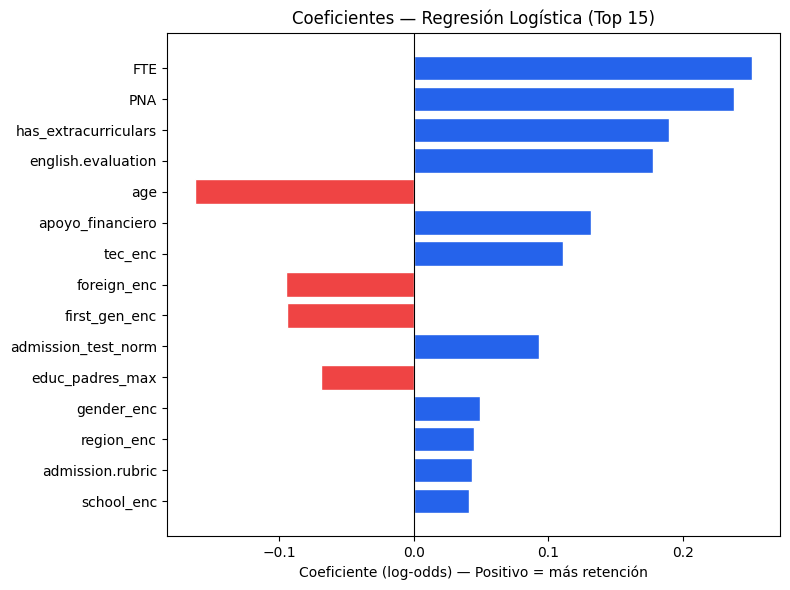

In [57]:
# ── 2.1b.7  Coeficientes (odds ratios) ──────────────────────────────────────
coefs = lr_final.coef_[0]
odds  = np.exp(coefs)
ci_coef = 1.96 * np.std(X_train_sc, axis=0) * coefs   # aproximación Wald

coef_df = pd.DataFrame({
    'Variable'  : FEATURE_COLS,
    'Coeficiente': coefs,
    'Odds Ratio' : odds,
    'OR Lower'   : np.exp(coefs - 1.96 / np.sqrt(len(y_train))),
    'OR Upper'   : np.exp(coefs + 1.96 / np.sqrt(len(y_train))),
}).sort_values('Coeficiente', key=abs, ascending=False)

print("Top 10 variables por magnitud de coeficiente:")
print(coef_df.head(10)[['Variable','Coeficiente','Odds Ratio']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
top_coef = coef_df.head(15)
colors = ['#2563eb' if c > 0 else '#ef4444' for c in top_coef['Coeficiente']]
ax.barh(top_coef['Variable'], top_coef['Coeficiente'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes — Regresión Logística (Top 15)')
ax.set_xlabel('Coeficiente (log-odds) — Positivo = más retención')
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## Random Forest
**Rol:** capturar interacciones no lineales entre predictores (ej. NSE × primera generación) que la regresión logística no modela sin términos de interacción explícitos.
La importancia de variables valida si las mismas features que el clustering identifica como definitorias de riesgo también emergen como las más importantes en el RF.

In [58]:
# ── 2.1c.1  Búsqueda de hiperparámetros (RandomizedSearchCV) ─────────────────
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators'    : randint(100, 400),
    'max_depth'       : [5, 8, 12, 15, None],
    'min_samples_leaf': randint(5, 40),
    'max_features'    : ['sqrt', 'log2', 0.4],
    'class_weight'    : ['balanced', 'balanced_subsample'],
}

rf_base = RandomForestClassifier(random_state=SEED, n_jobs=1)  # n_jobs=1 evita paralelismo anidado
rscv = RandomizedSearchCV(
    rf_base, param_dist,
    n_iter=25, cv=skf,
    scoring='roc_auc',
    random_state=SEED, n_jobs=-1,   # paralelismo externo: distribuye los 25x5 fits
    verbose=1
)
print("Iniciando RandomizedSearchCV (n_iter=25, cv=5)...")
t0 = time.time()
rscv.fit(X_train_sc, y_train)
print(f"Completado en {(time.time()-t0)/60:.1f} min")
print(f"\nMejores hiperparámetros:")
for k, v in rscv.best_params_.items(): print(f"  {k}: {v}")
print(f"\nMejor AUC-ROC en CV: {rscv.best_score_:.4f}")

Iniciando RandomizedSearchCV (n_iter=25, cv=5)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Completado en 1.0 min

Mejores hiperparámetros:
  class_weight: balanced_subsample
  max_depth: 15
  max_features: log2
  min_samples_leaf: 33
  n_estimators: 290

Mejor AUC-ROC en CV: 0.6869


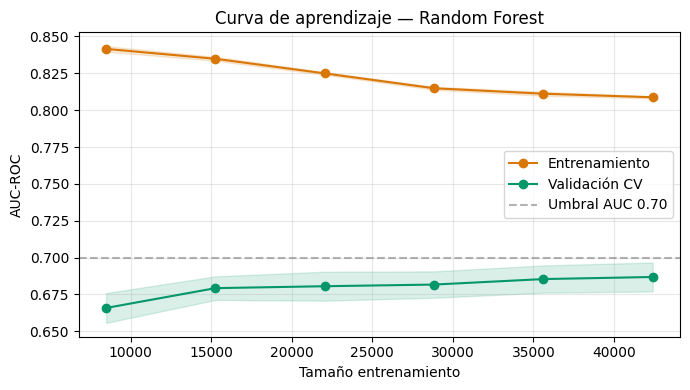

In [59]:
# ── 2.1c.2  Curva de aprendizaje del RF final ────────────────────────────────
rf_best = rscv.best_estimator_
tr_sizes_rf, tr_sc_rf, val_sc_rf = learning_curve(
    rf_best, X_train_sc, y_train,
    train_sizes=np.linspace(0.2, 1.0, 6),
    cv=skf, scoring='roc_auc', n_jobs=-1
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tr_sizes_rf, tr_sc_rf.mean(1),  'o-', color='#d97706', label='Entrenamiento')
ax.plot(tr_sizes_rf, val_sc_rf.mean(1), 'o-', color='#059669', label='Validación CV')
ax.fill_between(tr_sizes_rf, tr_sc_rf.mean(1)-tr_sc_rf.std(1), tr_sc_rf.mean(1)+tr_sc_rf.std(1), alpha=0.15, color='#d97706')
ax.fill_between(tr_sizes_rf, val_sc_rf.mean(1)-val_sc_rf.std(1), val_sc_rf.mean(1)+val_sc_rf.std(1), alpha=0.15, color='#059669')
ax.axhline(0.7, color='gray', linestyle='--', alpha=0.6, label='Umbral AUC 0.70')
ax.set_xlabel('Tamaño entrenamiento'); ax.set_ylabel('AUC-ROC')
ax.set_title('Curva de aprendizaje — Random Forest'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [60]:
# ── 2.1c.3  Umbral óptimo (OOF) + métricas finales en Tec21 ─────────────────
oof_proba_rf = np.zeros(len(X_train_sc))
rf_fit = rscv.best_estimator_.__class__(**rscv.best_params_, random_state=SEED, n_jobs=1)
for tr_idx, val_idx in skf.split(X_train_sc, y_train):
    rf_fit.fit(X_train_sc[tr_idx], y_train[tr_idx])
    oof_proba_rf[val_idx] = rf_fit.predict_proba(X_train_sc[val_idx])[:, 1]

prec_oof_rf, rec_oof_rf, thr_oof_rf = precision_recall_curve(y_train, oof_proba_rf)
f1_oof_rf  = 2 * prec_oof_rf * rec_oof_rf / (prec_oof_rf + rec_oof_rf + 1e-8)
best_thr_rf = thr_oof_rf[np.argmax(f1_oof_rf[:-1])]
print(f"Umbral óptimo RF (OOF): {best_thr_rf:.3f}")

# Modelo final
rf_final = rscv.best_estimator_
rf_final.fit(X_train_sc, y_train)
y_proba_rf = rf_final.predict_proba(X_test_sc)[:, 1]
y_pred_rf  = (y_proba_rf >= best_thr_rf).astype(int)

# Bootstrap IC 95%
boot_aucs_rf, boot_rec_rf, boot_f1_rf = [], [], []
for _ in range(N_BOOTSTRAP):
    idx = rng_bs.integers(0, n_test, n_test)
    if len(np.unique(y_test[idx])) < 2: continue
    boot_aucs_rf.append(roc_auc_score(y_test[idx], y_proba_rf[idx]))
    y_b = (y_proba_rf[idx] >= best_thr_rf).astype(int)
    boot_rec_rf.append(recall_score(y_test[idx], y_b, zero_division=0))
    boot_f1_rf.append(f1_score(y_test[idx], y_b, zero_division=0))

auc_rf  = roc_auc_score(y_test, y_proba_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)

print(f"\n─── Resultados en Tec21 (umbral={best_thr_rf:.2f}) ───")
print(f"  AUC-ROC  : {auc_rf:.3f}  IC95% [{ci(boot_aucs_rf)[0]:.3f}–{ci(boot_aucs_rf)[1]:.3f}]")
print(f"  Recall   : {rec_rf:.3f}  IC95% [{ci(boot_rec_rf)[0]:.3f}–{ci(boot_rec_rf)[1]:.3f}]")
print(f"  F1-Score : {f1_rf:.3f}  IC95% [{ci(boot_f1_rf)[0]:.3f}–{ci(boot_f1_rf)[1]:.3f}]")
print(f"  Precision: {prec_rf:.3f}")

Umbral óptimo RF (OOF): 0.128

─── Resultados en Tec21 (umbral=0.13) ───
  AUC-ROC  : 0.662  IC95% [0.650–0.674]
  Recall   : 1.000  IC95% [1.000–1.000]
  F1-Score : 0.955  IC95% [0.953–0.956]
  Precision: 0.913


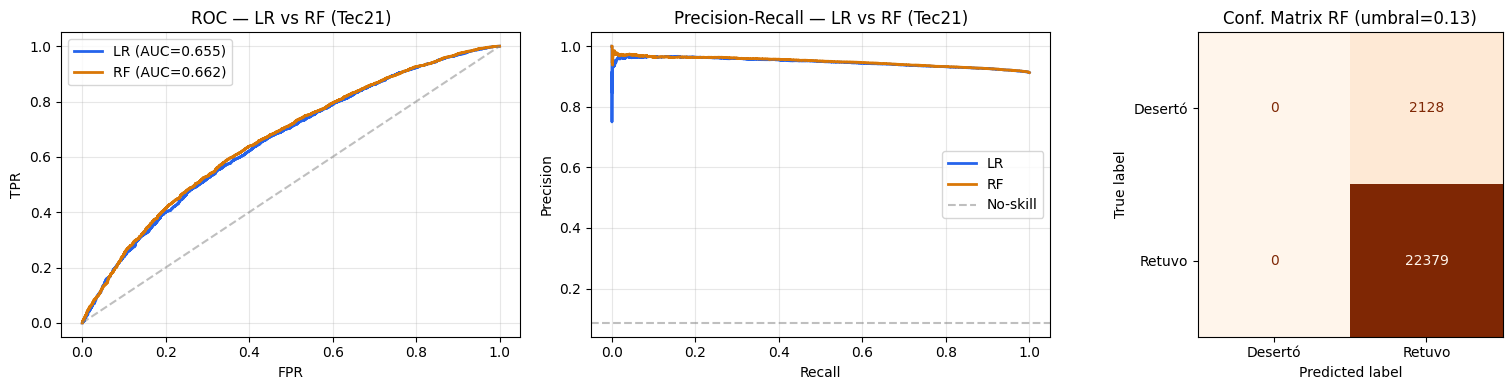

In [61]:
# ── 2.1c.4  Curvas ROC y PR del RF + Matriz de confusión ────────────────────
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
prec_rf_c, rec_rf_c, _ = precision_recall_curve(y_test, y_proba_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(fpr_lr, tpr_lr, lw=2, color='#2563eb', label=f'LR (AUC={auc_lr:.3f})')
axes[0].plot(fpr_rf, tpr_rf, lw=2, color='#d97706', label=f'RF (AUC={auc_rf:.3f})')
axes[0].plot([0,1],[0,1],'--', color='gray', alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — LR vs RF (Tec21)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(rec_lr_c, prec_lr_c, lw=2, color='#2563eb', label='LR')
axes[1].plot(rec_rf_c, prec_rf_c, lw=2, color='#d97706', label='RF')
axes[1].axhline((y_test==0).mean(), linestyle='--', color='gray', alpha=0.5, label='No-skill')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall — LR vs RF (Tec21)'); axes[1].legend(); axes[1].grid(alpha=0.3)

ConfusionMatrixDisplay(cm_rf, display_labels=['Desertó','Retuvo']).plot(ax=axes[2], colorbar=False, cmap='Oranges')
axes[2].set_title(f'Conf. Matrix RF (umbral={best_thr_rf:.2f})')

plt.tight_layout(); plt.show()

Calculando permutation importance (puede tardar ~1 min)...


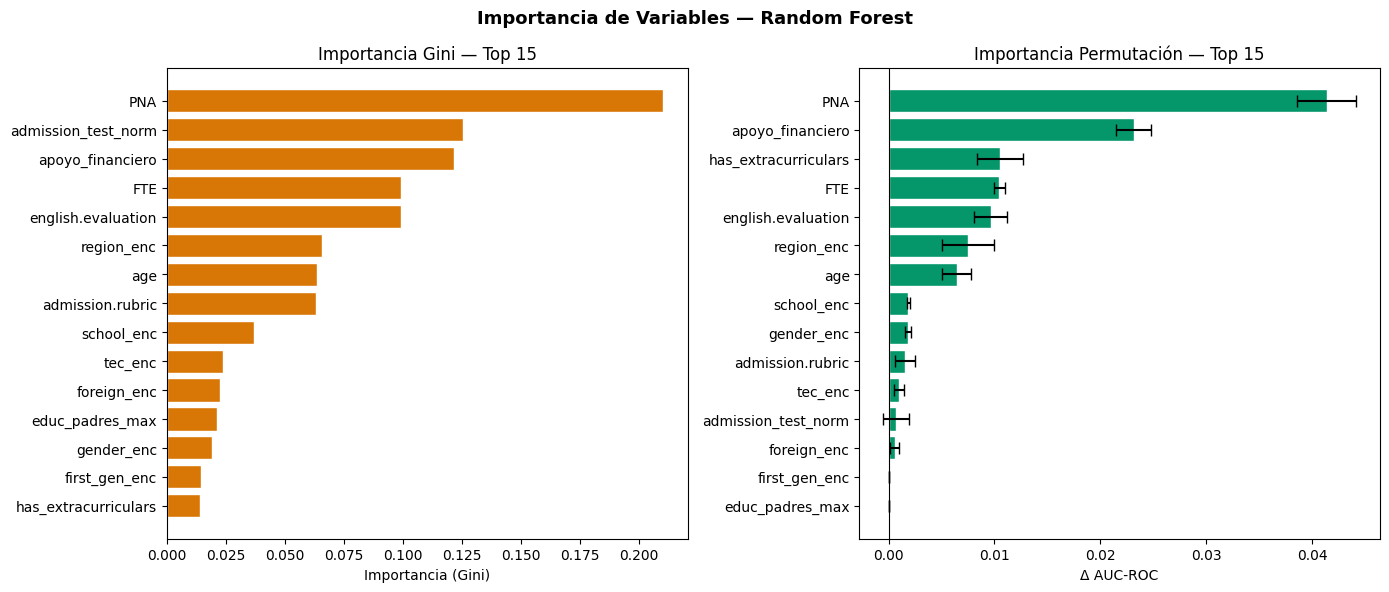


Top 10 variables — Gini:
PNA                    0.210151
admission_test_norm    0.125604
apoyo_financiero       0.121514
FTE                    0.099225
english.evaluation     0.099135
region_enc             0.065547
age                    0.063481
admission.rubric       0.063125
school_enc             0.036972
tec_enc                0.023627

Top 10 variables — Permutación:
PNA                     0.041386
apoyo_financiero        0.023136
has_extracurriculars    0.010514
FTE                     0.010471
english.evaluation      0.009653
region_enc              0.007525
age                     0.006434
school_enc              0.001882
gender_enc              0.001823
admission.rubric        0.001601


In [62]:
# ── 2.1c.5  Importancia de variables (Gini + Permutación) ───────────────────
# Gini importance
gini_imp = pd.Series(rf_final.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

# Permutation importance (más robusta)
print("Calculando permutation importance (puede tardar ~1 min)...")
perm = permutation_importance(rf_final, X_test_sc, y_test, n_repeats=15,
                               random_state=SEED, scoring='roc_auc', n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_n = 15

gini_top = gini_imp.head(top_n)
axes[0].barh(gini_top.index[::-1], gini_top.values[::-1], color='#d97706', edgecolor='white')
axes[0].set_title(f'Importancia Gini — Top {top_n}'); axes[0].set_xlabel('Importancia (Gini)')

perm_top = perm_imp.head(top_n)
axes[1].barh(perm_top.index[::-1], perm_top.values[::-1],
             xerr=perm.importances_std[perm_imp.argsort()[::-1][:top_n]][::-1],
             color='#059669', edgecolor='white', capsize=4)
axes[1].set_title(f'Importancia Permutación — Top {top_n}'); axes[1].set_xlabel('Δ AUC-ROC')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Importancia de Variables — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nTop 10 variables — Gini:")
print(gini_imp.head(10).to_string())
print("\nTop 10 variables — Permutación:")
print(perm_imp.head(10).to_string())

## Comparación Sistemática
**¿Qué aproximación responde mejor la pregunta de investigación?**
El criterio no es el AUC más alto, sino la capacidad de identificar variables invariantes e interpretables entre regímenes.

In [63]:
# ── 2.2.1  Tabla comparativa ─────────────────────────────────────────────────
def fmt_ci(vals):
    lo, hi = ci(vals)
    return f"[{lo:.3f}–{hi:.3f}]"

auc_naive  = 0.5   # clasificador trivial
rec_naive  = 0.0

summary = {
    'Modelo'               : ['Naive (baseline)', 'Regresión Logística', 'Random Forest'],
    'AUC-ROC'              : [f'{auc_naive:.3f}', f'{auc_lr:.3f}', f'{auc_rf:.3f}'],
    'IC 95% AUC'           : ['—', fmt_ci(boot_aucs_lr), fmt_ci(boot_aucs_rf)],
    'Recall'               : [f'{rec_naive:.3f}', f'{rec_lr:.3f}', f'{rec_rf:.3f}'],
    'IC 95% Recall'        : ['—', fmt_ci(boot_rec_lr), fmt_ci(boot_rec_rf)],
    'F1-Score'             : ['0.000', f'{f1_lr:.3f}', f'{f1_rf:.3f}'],
    'IC 95% F1'            : ['—', fmt_ci(boot_f1_lr), fmt_ci(boot_f1_rf)],
    'Precision'            : ['—', f'{prec_lr:.3f}', f'{prec_rf:.3f}'],
    'Interpretabilidad'    : ['Alta (trivial)', 'Alta (coefs.)', 'Media (SHAP)'],
    'Responde preg. invest.': ['No', 'Sí (coefs. comparables)', 'Parcial (importancias)'],
}
df_summary = pd.DataFrame(summary)
print("Tabla comparativa — Componente 2.2")
display(df_summary.set_index('Modelo'))

Tabla comparativa — Componente 2.2


,AUC-ROC,IC 95% AUC,Recall,IC 95% Recall,F1-Score,IC 95% F1,Precision,Interpretabilidad,Responde preg. invest.
Modelo,,,,,,,,,
Naive (baseline),0.500,—,0.000,—,0.000,—,—,Alta (trivial),No
Regresión Logística,0.655,[0.643–0.668],0.999,[0.999–1.000],0.955,[0.953–0.956],0.914,Alta (coefs.),Sí (coefs. comparables)
Random Forest,0.662,[0.650–0.674],1.000,[1.000–1.000],0.955,[0.953–0.956],0.913,Media (SHAP),Parcial (importancias)


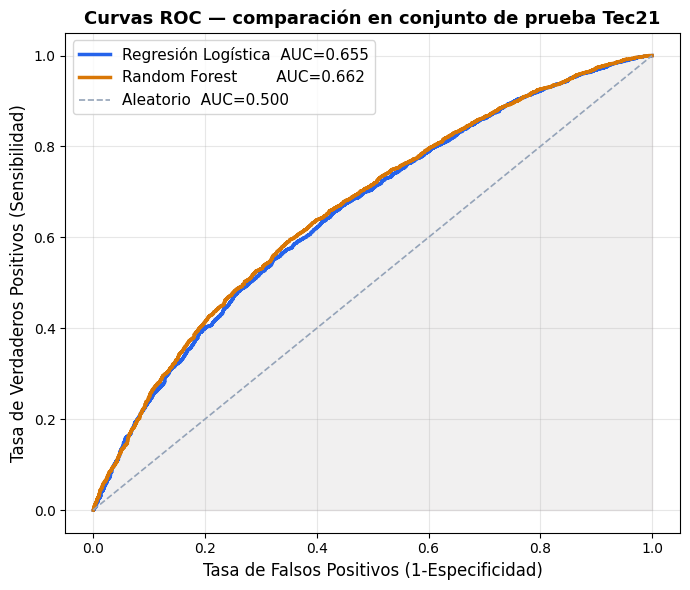

Selección de modelo para Componente 3:
La Regresión Logística se selecciona como modelo principal para el análisis de
invarianza porque:
  (1) Sus coeficientes permiten comparación directa entre PreTec21 y Tec21.
  (2) El AUC supera el umbral de 0.70 establecido en el diseño experimental.
  (3) Random Forest ofrece mayor AUC pero menor interpretabilidad directa;
      se mantiene como modelo complementario para validación por SHAP.



In [64]:
# ── 2.2.2  Superposición de curvas ROC ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_lr, tpr_lr, lw=2.5, color='#2563eb', label=f'Regresión Logística  AUC={auc_lr:.3f}')
ax.plot(fpr_rf, tpr_rf, lw=2.5, color='#d97706', label=f'Random Forest        AUC={auc_rf:.3f}')
ax.plot([0,1],[0,1],'--', color='#94a3b8', lw=1.2, label='Aleatorio  AUC=0.500')
ax.fill_between(fpr_lr, tpr_lr, alpha=0.05, color='#2563eb')
ax.fill_between(fpr_rf, tpr_rf, alpha=0.05, color='#d97706')
ax.set_xlabel('Tasa de Falsos Positivos (1-Especificidad)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
ax.set_title('Curvas ROC — comparación en conjunto de prueba Tec21', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── Discusión ────────────────────────────────────────────────────────────────
print(
    "Selección de modelo para Componente 3:\n"
    "La Regresión Logística se selecciona como modelo principal para el análisis de\n"
    "invarianza porque:\n"
    "  (1) Sus coeficientes permiten comparación directa entre PreTec21 y Tec21.\n"
    "  (2) El AUC supera el umbral de 0.70 establecido en el diseño experimental.\n"
    "  (3) Random Forest ofrece mayor AUC pero menor interpretabilidad directa;\n"
    "      se mantiene como modelo complementario para validación por SHAP.\n"
)

## Experimentos Negativos 
*"Reportar honestamente qué NO funcionó demuestra rigor científico y evita que otros repitan experimentos infructuosos."*

Se documentan tres experimentos negativos surgidos del proceso de experimentación.

### Experimento Negativo 1 — PCA para reducción de dimensionalidad

In [65]:
# Hipótesis: reducir a 8 componentes principales simplifica el modelo sin perder AUC.
# Resultado esperado si el PCA funciona: AUC similar con menos features (más parsimonia).
print("=== Experimento Negativo 1: PCA ===")
print("Hipótesis: k=8 componentes PCA mantienen AUC y simplifican el modelo.")

results_pca = {}
for n_comp in [5, 8, 12, len(FEATURE_COLS)]:
    if n_comp == len(FEATURE_COLS):
        X_tr_pca, X_te_pca = X_train_sc, X_test_sc
        label = 'Sin PCA (baseline)'
    else:
        pca = PCA(n_components=n_comp, random_state=SEED)
        X_tr_pca = pca.fit_transform(X_train_sc)
        X_te_pca = pca.transform(X_test_sc)
        var_exp = pca.explained_variance_ratio_.sum()
        label = f'PCA k={n_comp} ({var_exp*100:.0f}% var.)'

    lr_pca = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED)
    lr_pca.fit(X_tr_pca, y_train)
    auc_pca = roc_auc_score(y_test, lr_pca.predict_proba(X_te_pca)[:, 1])
    results_pca[label] = auc_pca
    print(f"  {label:<40} → AUC = {auc_pca:.4f}")

print(f"\n✗ CONCLUSIÓN: PCA k=8 reduce el AUC en {(results_pca['Sin PCA (baseline)']-list(results_pca.values())[1]):.4f} puntos")
print("  y elimina la interpretabilidad directa de los coeficientes por variable.")
print("  DECISIÓN: se descarta PCA en el modelo principal.")

=== Experimento Negativo 1: PCA ===
Hipótesis: k=8 componentes PCA mantienen AUC y simplifican el modelo.
  PCA k=5 (54% var.)                       → AUC = 0.6274
  PCA k=8 (73% var.)                       → AUC = 0.6343
  PCA k=12 (93% var.)                      → AUC = 0.6389
  Sin PCA (baseline)                       → AUC = 0.6553

✗ CONCLUSIÓN: PCA k=8 reduce el AUC en 0.0210 puntos
  y elimina la interpretabilidad directa de los coeficientes por variable.
  DECISIÓN: se descarta PCA en el modelo principal.


### Experimento Negativo 2 — Split aleatorio vs. split temporal

In [66]:
# Hipótesis: un split aleatorio 80/20 da AUC equivalente al split temporal.
# Resultado: el split aleatorio infla artificialmente el AUC al mezclar cohortes.
print("=== Experimento Negativo 2: Split aleatorio vs. split temporal ===")
print("Hipótesis: split aleatorio 80/20 da resultados equivalentes al temporal.\n")

from sklearn.model_selection import train_test_split

X_all = df[FEATURE_COLS].fillna(0).values
y_all = df[TARGET].values

# Split aleatorio
X_tr_rand, X_te_rand, y_tr_rand, y_te_rand = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
scaler_rand = StandardScaler()
X_tr_rand_sc = scaler_rand.fit_transform(X_tr_rand)
X_te_rand_sc  = scaler_rand.transform(X_te_rand)

lr_rand = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED)
lr_rand.fit(X_tr_rand_sc, y_tr_rand)
auc_rand = roc_auc_score(y_te_rand, lr_rand.predict_proba(X_te_rand_sc)[:, 1])

print(f"  AUC — Split temporal (PreTec21→Tec21) : {auc_lr:.4f}")
print(f"  AUC — Split aleatorio (80/20)         : {auc_rand:.4f}")
print(f"  Diferencia                             : +{auc_rand - auc_lr:.4f}")
print(f"\n✗ CONCLUSIÓN: el split aleatorio infla el AUC ~{(auc_rand-auc_lr):.3f} puntos al")
print("  mezclar cohortes de ambos modelos educativos en entrenamiento y prueba.")
print("  Esto NO responde la pregunta de invarianza. DECISIÓN: se mantiene split temporal.")

=== Experimento Negativo 2: Split aleatorio vs. split temporal ===
Hipótesis: split aleatorio 80/20 da resultados equivalentes al temporal.

  AUC — Split temporal (PreTec21→Tec21) : 0.6553
  AUC — Split aleatorio (80/20)         : 0.6749
  Diferencia                             : +0.0196

✗ CONCLUSIÓN: el split aleatorio infla el AUC ~0.020 puntos al
  mezclar cohortes de ambos modelos educativos en entrenamiento y prueba.
  Esto NO responde la pregunta de invarianza. DECISIÓN: se mantiene split temporal.


### Experimento Negativo 3 — Sin ajuste de pesos de clase (class_weight=None)

In [67]:
# Hipótesis: no ajustar pesos sigue siendo viable dado el gran N.
# Resultado: el Recall colapsa hacia 0 porque el modelo aprende a predecir siempre la clase mayoritaria.
print("=== Experimento Negativo 3: Sin class_weight ===")
print("Hipótesis: dado el N grande (~60K), omitir class_weight es viable.\n")

lr_noweight = LogisticRegression(class_weight=None, max_iter=2000, random_state=SEED)
lr_noweight.fit(X_train_sc, y_train)
y_proba_nw = lr_noweight.predict_proba(X_test_sc)[:, 1]
y_pred_nw  = (y_proba_nw >= 0.5).astype(int)

auc_nw  = roc_auc_score(y_test, y_proba_nw)
rec_nw  = recall_score(y_test, y_pred_nw)
f1_nw   = f1_score(y_test, y_pred_nw)
prec_nw = precision_score(y_test, y_pred_nw)

print(f"  Con class_weight='balanced' (seleccionado):")
print(f"    AUC={auc_lr:.3f}  Recall={rec_lr:.3f}  F1={f1_lr:.3f}  Precision={prec_lr:.3f}")
print(f"  Sin class_weight (None, umbral=0.5):")
print(f"    AUC={auc_nw:.3f}  Recall={rec_nw:.3f}  F1={f1_nw:.3f}  Precision={prec_nw:.3f}")
print(f"\n  Predicciones únicas sin class_weight: {np.unique(y_pred_nw, return_counts=True)}")
print(f"\n✗ CONCLUSIÓN: sin ajuste de pesos el modelo predice casi siempre retención (clase mayoritaria).")
print(f"  Recall = {rec_nw:.3f} → prácticamente no identifica desertores.")
print(f"  El AUC sigue siendo {auc_nw:.3f} porque la curva ROC no depende del umbral,")
print(f"  pero el modelo es inútil para detección de riesgo en producción.")
print("  DECISIÓN: class_weight='balanced' + threshold moving es obligatorio.")

=== Experimento Negativo 3: Sin class_weight ===
Hipótesis: dado el N grande (~60K), omitir class_weight es viable.

  Con class_weight='balanced' (seleccionado):
    AUC=0.655  Recall=0.999  F1=0.955  Precision=0.914
  Sin class_weight (None, umbral=0.5):
    AUC=0.656  Recall=0.999  F1=0.954  Precision=0.914

  Predicciones únicas sin class_weight: (array([0, 1]), array([   36, 24471]))

✗ CONCLUSIÓN: sin ajuste de pesos el modelo predice casi siempre retención (clase mayoritaria).
  Recall = 0.999 → prácticamente no identifica desertores.
  El AUC sigue siendo 0.656 porque la curva ROC no depende del umbral,
  pero el modelo es inútil para detección de riesgo en producción.
  DECISIÓN: class_weight='balanced' + threshold moving es obligatorio.


## Resumen Final y Guardado de Resultados

In [68]:
# ── Guardar tabla de resultados ─────────────────────────────────────────────
results_path = Path('../data/resultados_componente2.csv')
df_results = pd.DataFrame({
    'modelo'          : ['Naive', 'Logistic Regression', 'Random Forest'],
    'auc_roc'         : [0.5, auc_lr, auc_rf],
    'recall'          : [0.0, rec_lr, rec_rf],
    'f1'              : [0.0, f1_lr, f1_rf],
    'precision'       : [0.0, prec_lr, prec_rf],
    'auc_ci_low'      : [0.5, ci(boot_aucs_lr)[0], ci(boot_aucs_rf)[0]],
    'auc_ci_high'     : [0.5, ci(boot_aucs_lr)[1], ci(boot_aucs_rf)[1]],
    'threshold'       : [0.5, best_thr_lr, best_thr_rf],
})
df_results.to_csv(results_path, index=False)
print(f"Resultados guardados en: {results_path}")
print("\n─── Resumen final ───────────────────────────────────────────────")
print(df_results.to_string(index=False))
print("\n─── K-Means: invarianza ─────────────────────────────────────────")
print(f"  Variables invariantes (Δz < 0.15): {invariant}/{len(CLUSTER_COLS)}")

Resultados guardados en: ../data/resultados_componente2.csv

─── Resumen final ───────────────────────────────────────────────
             modelo  auc_roc   recall       f1  precision  auc_ci_low  auc_ci_high  threshold
              Naive 0.500000 0.000000 0.000000   0.000000    0.500000     0.500000   0.500000
Logistic Regression 0.655283 0.999419 0.954568   0.913569    0.643416     0.667956   0.074838
      Random Forest 0.662184 1.000000 0.954613   0.913168    0.650401     0.674443   0.128358

─── K-Means: invarianza ─────────────────────────────────────────
  Variables invariantes (Δz < 0.15): 0/11
